# The "aprox13" network

The aprox13 network is widely used for explosive He burning in multidimensional simulations.  It has 2 main approximations:

* C+C, C+O, and O+O burning are simplified, removing the intermediate nucleus from the proton emission branch and neglecting the neutron-emission branch
* The $(\alpha,p)(p,\gamma)$ links are combined with $(\alpha,\gamma)$

We can do both approximations.

## A starting network

To begin, we'll create a network will all of the nuclei (including those that will be approximated out later).  We'll use {py:func}`network_helper <pynucastro.networks.helper.network_helper>` so we automatically rederive reverse rates using detailed balance.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"])

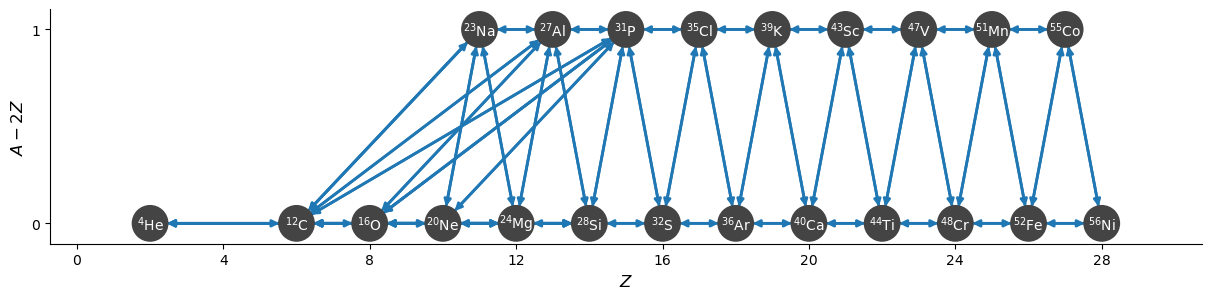

In [3]:
fig = net.plot(rotated=True,
               size=(1200, 300), node_size=600, node_font_size=10)

In [4]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 23
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 92

  rates explicitly connecting nuclei: 92
  hidden rates: 0

  reaclib rates: 46
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 46
  modified rates: 0
  custom rates: 0


## Approximating

Now we'll approximate the C/O burning

In [5]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [6]:
approx_net = pyna.PythonNetwork(rates=net.get_rates())

In [7]:
approx_net.make_CO_burning_approx("C")
approx_net.remove_nuclei(["na23"])

In [8]:
approx_net.make_CO_burning_approx("CO")
approx_net.remove_nuclei(["al27"])

In [9]:
approx_net.make_CO_burning_approx("O")
approx_net.remove_nuclei(["p31"])

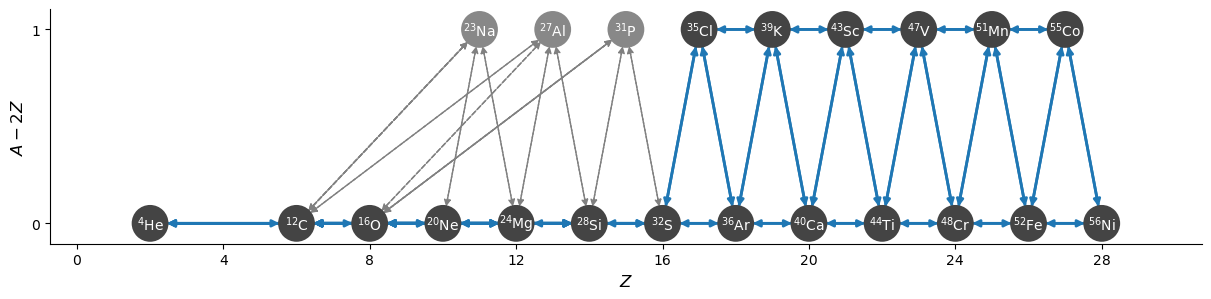

In [10]:
fig = approx_net.plot(rotated=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

now the $(\alpha,p)(p,\gamma)$ approximation

In [11]:
approx_net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
approx_net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

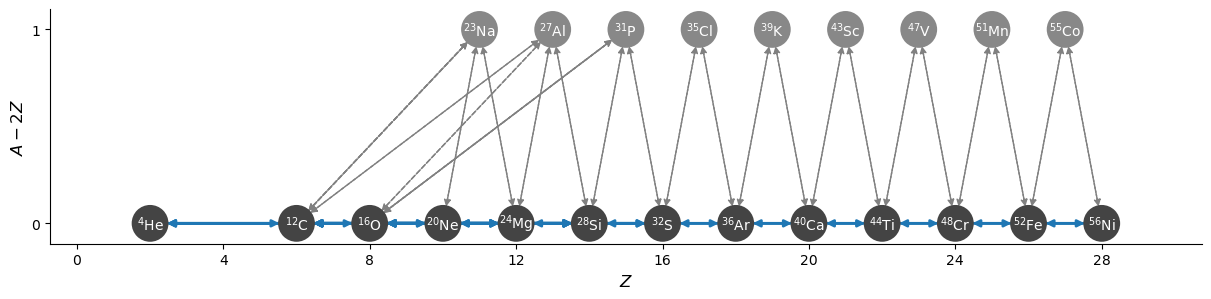

In [12]:
fig = approx_net.plot(rotated=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

## Comparing the integration

### the full network

In [13]:
net.write_network("full_aprox13.py")
import full_aprox13 as fn

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [14]:
rho = 1.e7
T = 3.e9

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 1.0
Y0 = list(comp.get_molar().values())

In [15]:
tmax = 1000.0

In [16]:
sol_full = net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6)

/raid/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


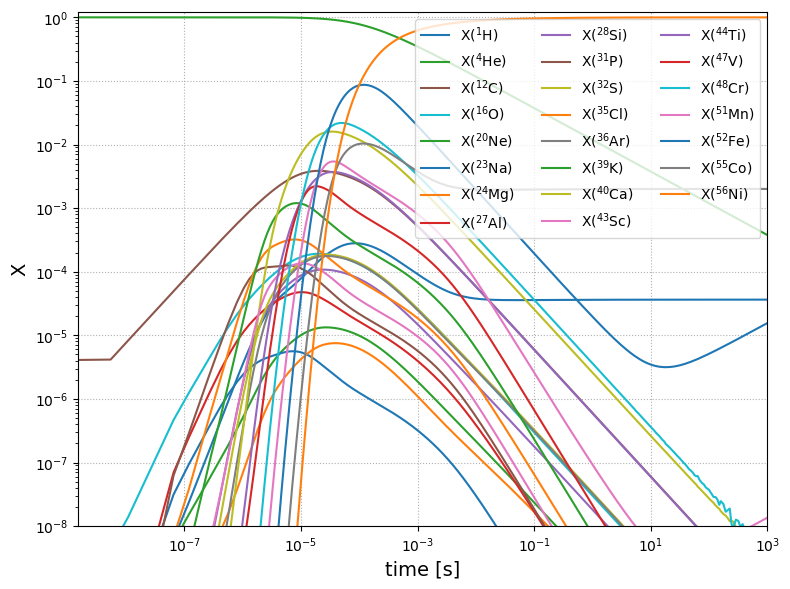

In [17]:
fig = sol_full.plot_evolution(ymin=1.e-8)

### aprox13 net

In [18]:
comp = pyna.Composition(approx_net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 1.0
Y0 = list(comp.get_molar().values())

In [19]:
sol_approx = approx_net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6)

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/raid/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


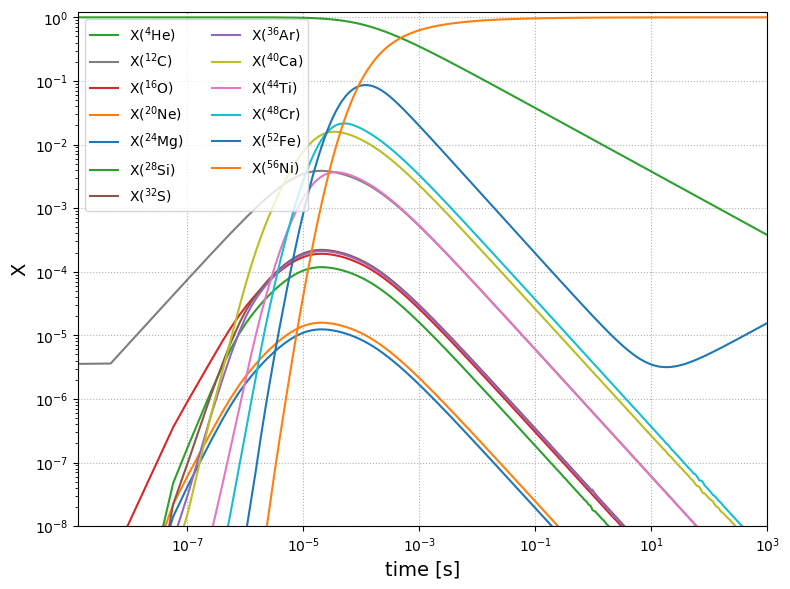

In [20]:
fig = sol_approx.plot_evolution(ymin=1.e-8)

### Comparing

In [21]:
import matplotlib.pyplot as plt

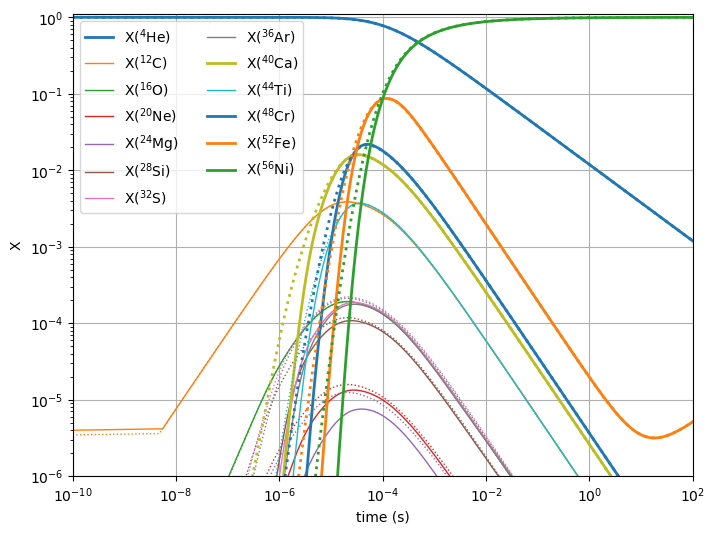

In [22]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_approx.unique_nuclei):
    lw = 1
    if sol_approx.X[i, :].max() > 1.e-2:
        lw = 2
    ax.loglog(sol_approx.t, sol_approx.X[i, :],
              linestyle=":", color=f"C{i}", lw=lw)    
    idx = sol_full.unique_nuclei.index(nuc)
    ax.loglog(sol_full.t, sol_full.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}", lw=lw)

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-10, 100)
fig.set_size_inches((8,6))
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend(ncol=2)
ax.grid()

We see good agreement for the nuclei the two networks have in common.